In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [2]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "spiders"
output_folder.mkdir(exist_ok=True)


In [3]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
print(info_mami.columns)

Index(['Unnamed: 0', 'animal', 'common_name', 'name', 'species', 'genus',
       'sub_family', 'family', 'sub_order', 'order', 'super_order',
       'phylogenetic_group', 'brain_weight_g', 'brain_volume_cm3',
       'brain_data_source'],
      dtype='object')


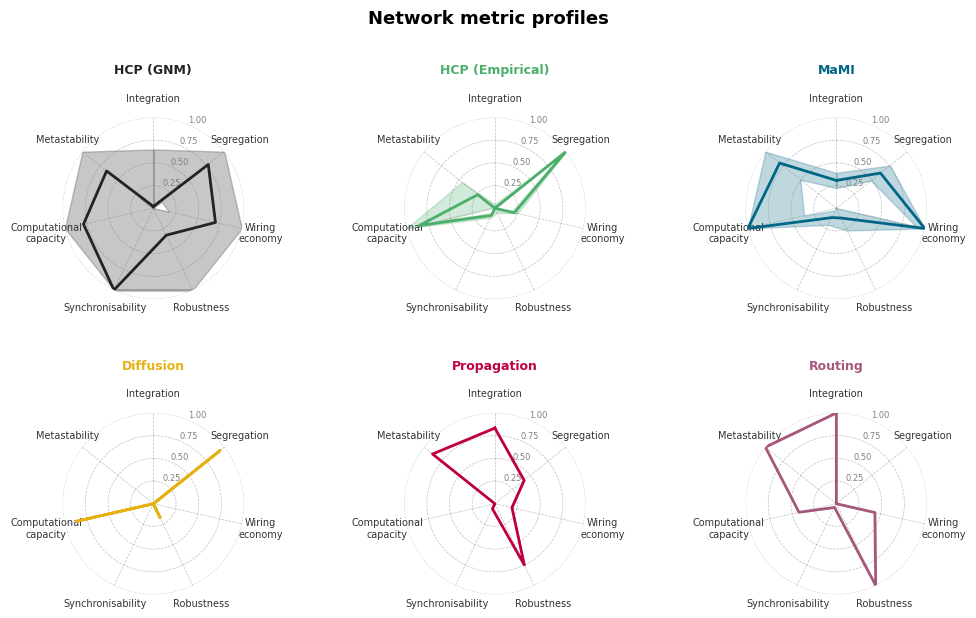

In [ ]:


# selected_properties = {
#     "Integration": ["global_efficiency"], # , "char_path_length"],
#     "Segregation": ["modularity"], # , "avg_communicability"],
#     "Wiring\neconomy": ["proportion_long_range_connections_0.5"], # "wiring_cost", "algebraic_connectivity_fiedler_value"],
#     "Robustness": ["synchronizability_eigenratio_lambda_2"], # "targeted_attack_robustness_rob_ratio", "persistent_homology_ph_total_persistence"],
#     "Synchronisability": ["synchronizability_eigenratio_eigenratio"], # "synchronisability", "synchronisability_normalised"],
#     "Computational\ncapacity": ["computational_capacity_total_capacity"], # "computational_capacity", "computational_capacity_normalised"],
#     "Metastability": ["kuramoto_averaged_synchronization_r_std"], # "metastability", "metastability_normalised"],
# }

"global_efficiency"       
"algebraic_connectivity_fiedler_value"         
"targeted_attack_robustness_rob_targeted_auc" 
"proportion_long_range_connections_0.3956" 
"mc_mean"
"mc_nonlin_mean"
"repertoire_sweep_weighted_by_distances_diversity_critical"
"spectral_radius"        
"modularity"         


selected_properties = {
    "Integration": ["global_efficiency"], # , "char_path_length"],
    "Segregation": ["modularity"], # , "avg_communicability"],
    "Wiring\neconomy": ["proportion_long_range_connections_0.5"], # "wiring_cost", "algebraic_connectivity_fiedler_value"],
    "Robustness": ["synchronizability_eigenratio_lambda_2"], # "targeted_attack_robustness_rob_ratio", "persistent_homology_ph_total_persistence"],
    "Synchronisability": ["synchronizability_eigenratio_eigenratio"], # "synchronisability", "synchronisability_normalised"],
    "Computational\ncapacity": ["computational_capacity_total_capacity"], # "computational_capacity", "computational_capacity_normalised"],
    "Metastability": ["kuramoto_averaged_synchronization_r_std"], # "metastability", "metastability_normalised"],
}

SELECTED_COLS = []
for prop, metrics in selected_properties.items():
    if metrics:
        SELECTED_COLS.extend(metrics)
    else:
        print(f"Warning: No metrics selected for property '{prop}'")
        

N_SAMPLE = 100
SEED     = 42

# ── 2. Sample & aggregate ─────────────────────────────────────────────────────
def get_stats(df, cols, n_sample, seed):
    """Return (mean_series, std_series) for the selected cols."""
    sub = df[cols].dropna()
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=seed)
    return sub.mean(), sub.std(ddof=0).fillna(0)


datasets_to_look_at = ['hcp_schaefer_100_dataset_gnm', 
                       'hcp_schaefer_100_dataset', 
                       'suarez_MaMI_dataset',
                       'kaysons_generated_networks_diffusion', 
                       'kaysons_generated_networks_propagation', 
                       'kaysons_generated_networks_routing', 
                    #    'kaysons_generated_networks_topology', 
                       ]
stats = {}
for name in datasets_to_look_at: # df in dict_with_all_datasets.items():
    df = dict_with_all_datasets[name]
    stats[name] = get_stats(df, SELECTED_COLS, N_SAMPLE, SEED)



# ── 3. Normalise across ALL datasets so axes are [0, 1] ──────────────────────
all_means = pd.DataFrame({k: v[0] for k, v in stats.items()}).T   # datasets × cols
col_min   = all_means.min()
col_max   = all_means.max()
col_range = (col_max - col_min).replace(0, 1)   # avoid /0
COL_RANGE = col_range
COL_MIN = col_min


def normalise(series):
    return (series - COL_MIN) / COL_RANGE


# ── 4. Spider-plot helper ─────────────────────────────────────────────────────
def make_spider(ax, values, errors, labels, color, title, alpha_fill=0.20):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]                        # close the loop

    vals = list(values) + [values[0]]
    errs = list(errors) + [errors[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, vals, color=color, linewidth=2)
    # ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # ±1 std shaded band
    upper = np.clip(np.array(vals) + np.array(errs), 0, 1)
    lower = np.clip(np.array(vals) - np.array(errs), 0, 1)
    ax.fill_between(angles, lower, upper, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace('_', '\n') for l in labels],
        fontsize=7, color='#333333'
    )
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6, color='grey')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=14,
                 color=color, wrap=True)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.spines['polar'].set_visible(False)



# ── 5. Draw ───────────────────────────────────────────────────────────────────
n_datasets = len(stats)

ncols = 3
nrows = int(np.ceil(n_datasets / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.6, nrows * 3.6),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (name, (mean_raw, std_raw)) in enumerate(stats.items()):
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / COL_RANGE).values          # scale std the same way
    color  = COLOR_SCHEME[name] 

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(),
        color  = color,
        title  = LABEL_MAP[name],
    )

# hide unused axes
for ax in axes_flat[n_datasets:]:
    ax.set_visible(False)

fig.suptitle('Network metric profiles', #  (normalised) - mean ± std',
             fontsize=13, fontweight='bold', y=0.9) #1.01)
plt.tight_layout(pad=4)
# plt.savefig('spider_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Remove row 95 
dict_with_all_datasets['suarez_MaMI_dataset'] = dict_with_all_datasets['suarez_MaMI_dataset'][dict_with_all_datasets['suarez_MaMI_dataset'].index != 95]

['Chiroptera',
 'Marsupialia',
 'Cetartiodactyla',
 'Hyracoidea',
 'Xenarthra',
 'Lagomorpha',
 'Eulipotyphla',
 'Perissodactyla',
 'Rodentia',
 'Carnivora',
 'Scandentia',
 'Primates']

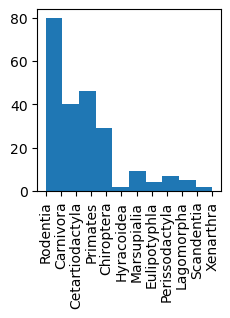

In [6]:
plt.figure(figsize=viz.cm_to_inch((6,6)))
plt.hist(info_mami["order"]) 
plt.xticks(rotation=90)
list(set(info_mami["order"]))

✓ Keeping 4 group(s): ['Carnivora', 'Cetartiodactyla', 'Primates', 'Rodentia']

Animals per 'order':
order
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51

→ Minimum group size: 29 (Rodentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_2150/3344084702.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


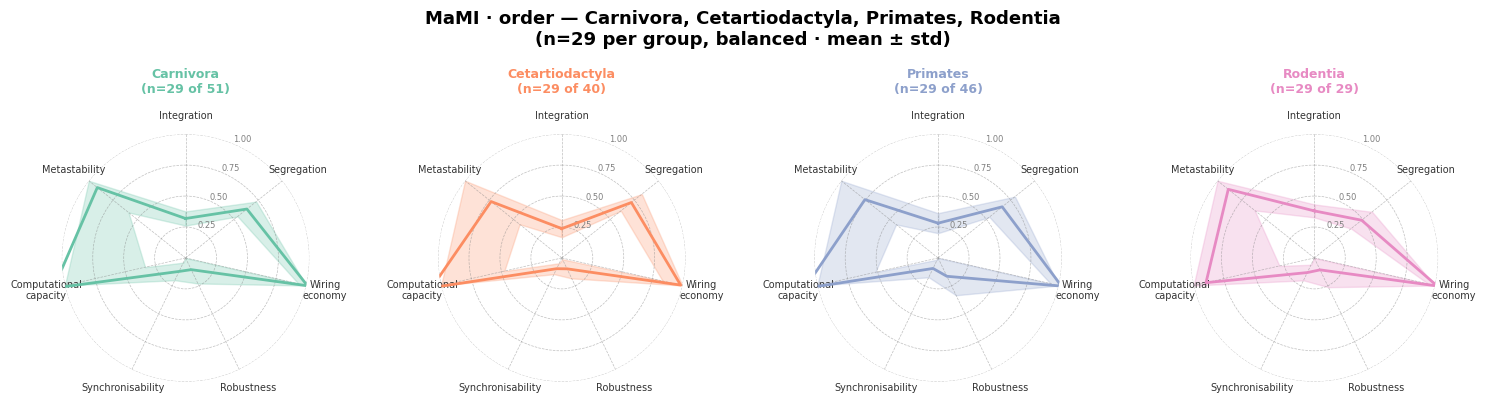

Saved → spider_mami_order.png


In [7]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "order"
GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
# g_range = (g_max - g_min).replace(0, 1)

g_range = COL_RANGE
# def normalise_mami(series):
#     return (series - g_min) / COL_RANGE #  g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / COL_RANGE).values
    # std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI · {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

✓ Keeping 4 group(s): ['Carnivora', 'Cetartiodactyla', 'Primates', 'Rodentia']

Animals per 'order':
order
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51

→ Minimum group size: 29 (Rodentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_2150/2124136765.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


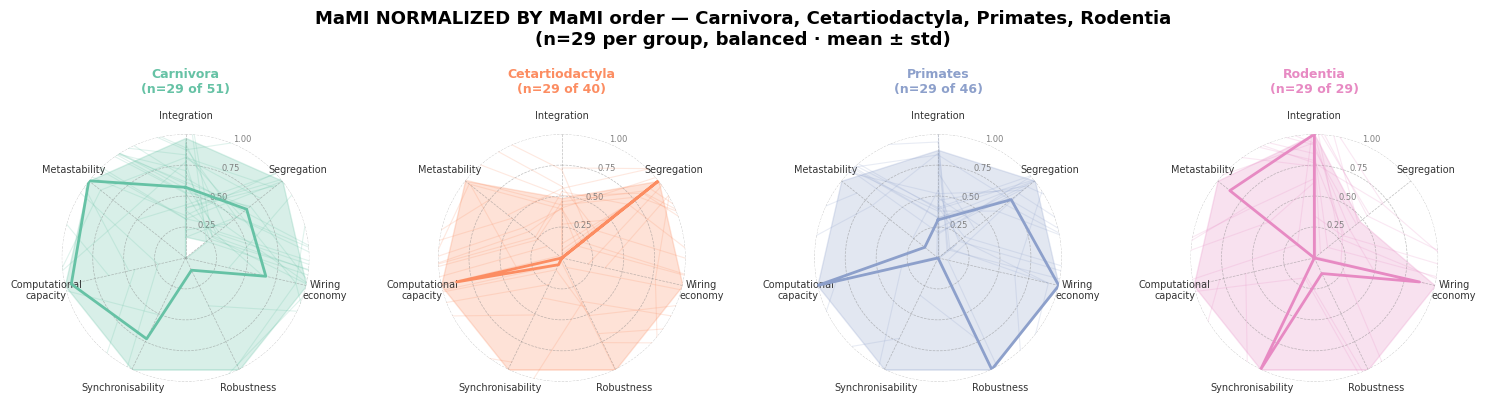

Saved → spider_mami_order.png


In [17]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "order"
GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

# g_range = COL_RANGE
def normalise_mami(series):
    return (series - g_min) / g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise_mami(mean_raw).values
    # std_n  = (std_raw / COL_RANGE).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]
    ax = axes_flat[idx]
    
    # ── Individual animal contours (low alpha) ────────────────────────────
    group_df = sampled[sampled[what_to_look_at] == group][SELECTED_COLS]
    n_cols   = len(SELECTED_COLS)
    angles   = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
    angles  += angles[:1]  # close the polygon

    for _, row in group_df.iterrows():
        ind_n  = normalise_mami(row).values.tolist()
        ind_n += ind_n[:1]  # close the polygon
        ax.plot(angles, ind_n, color=color, alpha=0.2, # 12, 
                linewidth=0.8)
        # ax.fill(angles, ind_n, color=color, alpha=0.03)
        

    make_spider(
        ax     = ax,
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI NORMALIZED BY MaMI {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

In [30]:
# Sort by alphabet and print
print(sorted(set(info_mami["name"])))

info_mami["name_cleaned"] = info_mami["name"].str.replace(" ", "_").str.lower()


['Addax', 'Agouti', 'Armadillo', 'Artibeus Jamacien', 'Asellia', 'Asian Otter', 'Baboon', 'Bactrian Deer', 'Battongia', 'Blanford Fox', 'Blind Mole', 'Bottle Nose Dolphin', 'Brown Lemur', 'Capra Nubiana', 'Capuchin', 'Capybara', 'Caracal', 'Carollia Perspicilatta', 'Cat', 'Caucasian Squirrel', 'Chaerephon Plicata', 'Chimpanzee', 'Chinchila', 'Chital', 'Colobus', 'Common Fox', 'Common Hedge Hog', 'Common Tree Shrew', 'Cow', 'Coypu', 'Cynopterus', 'Deer', 'Dego', 'Dik Dik', 'Dog', 'Donkey', 'Eonycteris', 'Eptesicus', 'Fallow Deer', 'Fennek Fox', 'Ferret', 'Fruit Bat', 'Gerbil', 'Giraffe', 'Goat', 'Golden Spiny Mouse', 'Gorilla', 'Gray Kangaroo', 'Green Monkey', 'Hare', 'Himalian Bear', 'Hipp Armiger', 'Honey Badger', 'Horse', 'Howler Monkey', 'Hyaena', 'Hyrax', 'Ind Hog Deer', 'Jungle Cat', 'Koala', 'Lama', 'Lemur Catta', 'Leopard', 'Lycaon', 'Macaque', 'Macaque Black', 'Macaque Lion Tail', 'Macaque P T', 'Mandrill', 'Mangebi', 'Mara', 'Marmoset', 'Meerkat', 'Merion', 'Miniopterus Schrei

In [32]:
# Replace the following: 
info_mami["name_cleaned"] = info_mami["name_cleaned"].replace({
    "stripped_dolphin": "dolphin", # stripped_
    "macaque_black": "macaque", # _black",
    "macaque_lion_tail": "macaque",
    "macaque_p_t": "macaque",
    "marmoset": "marmoset",
    "mouse": "mouse",
    "rabbit": "rabbit",
    "rat": "rat"
})

In [ ]:
# "Chimpanzee", "Dog", "Cat", "Dolphin", "Stripped Dolphin", "Macaque", "Macaque Black", "Macaque Lion Tail", "Macaque P T", "Marmoset", "Mouse", "Rabbit", "Rat"

In [35]:
# Count occurrences of each name
name_counts = info_mami["name_cleaned"].value_counts()
for i,n in name_counts.items():
    print(f"{i}: {n}")

macaque: 11
dog: 7
rat: 6
cat: 6
meerkat: 5
fruit_bat: 5
baboon: 5
capra_nubiana: 4
ferret: 4
nasua: 3
lycaon: 3
goat: 3
capuchin: 3
otter: 3
wolf: 3
brown_lemur: 3
giraffe: 3
fallow_deer: 3
red_kangaroo: 3
wild_rabbit: 3
common_hedge_hog: 3
orangutan: 3
oryx: 3
lama: 2
tapir: 2
gray_kangaroo: 2
howler_monkey: 2
tamarin_emperor: 2
eptesicus: 2
porcupine: 2
pkuhlii: 2
wild_rat: 2
horse: 2
bactrian_deer: 2
leopard: 2
wild_boar: 2
tamarin_cotton_top: 2
pecari: 2
chital: 2
tadarida_teniotis: 2
carollia_perspicilatta: 2
mandrill: 2
green_monkey: 2
dolphin: 2
blind_mole: 2
sand_cat: 2
agouti: 2
deer: 2
hyrax: 2
eonycteris: 2
hyaena: 2
vampire_bat: 2
porcine: 2
battongia: 2
lemur_catta: 2
artibeus_jamacien: 1
common_tree_shrew: 1
pteropus_lylei: 1
sand_hedge_hog: 1
capybara: 1
spiny_mouse: 1
asian_otter: 1
honey_badger: 1
colobus: 1
zebra: 1
armadillo: 1
donkey: 1
gorilla: 1
chimpanzee: 1
gerbil: 1
cow: 1
sheep: 1
tiger: 1
common_fox: 1
hipp_armiger: 1
ind_hog_deer: 1
coypu: 1
bottle_nose_dol

In [ ]:
name_counts.keys()[:9]

Index(['macaque', 'dog', 'rat', 'cat', 'meerkat', 'fruit_bat', 'baboon',
       'capra_nubiana', 'ferret', 'nasua',
       ...
       'red_panda', 'myotis_vivesi', 'jungle_cat', 'mara', 'fennek_fox',
       'mouse', 'vole', 'rabbit', 'caracal', 'mangebi'],
      dtype='object', name='name_cleaned', length=120)

✓ Keeping 9 group(s): ['baboon', 'capra_nubiana', 'cat', 'dog', 'ferret', 'fruit_bat', 'macaque', 'meerkat', 'rat']

Animals per 'name_cleaned':
name_cleaned
capra_nubiana     4
ferret            4
baboon            5
fruit_bat         5
meerkat           5
cat               6
rat               6
dog               7
macaque          11

→ Minimum group size: 4 (capra_nubiana)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_2150/677105600.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


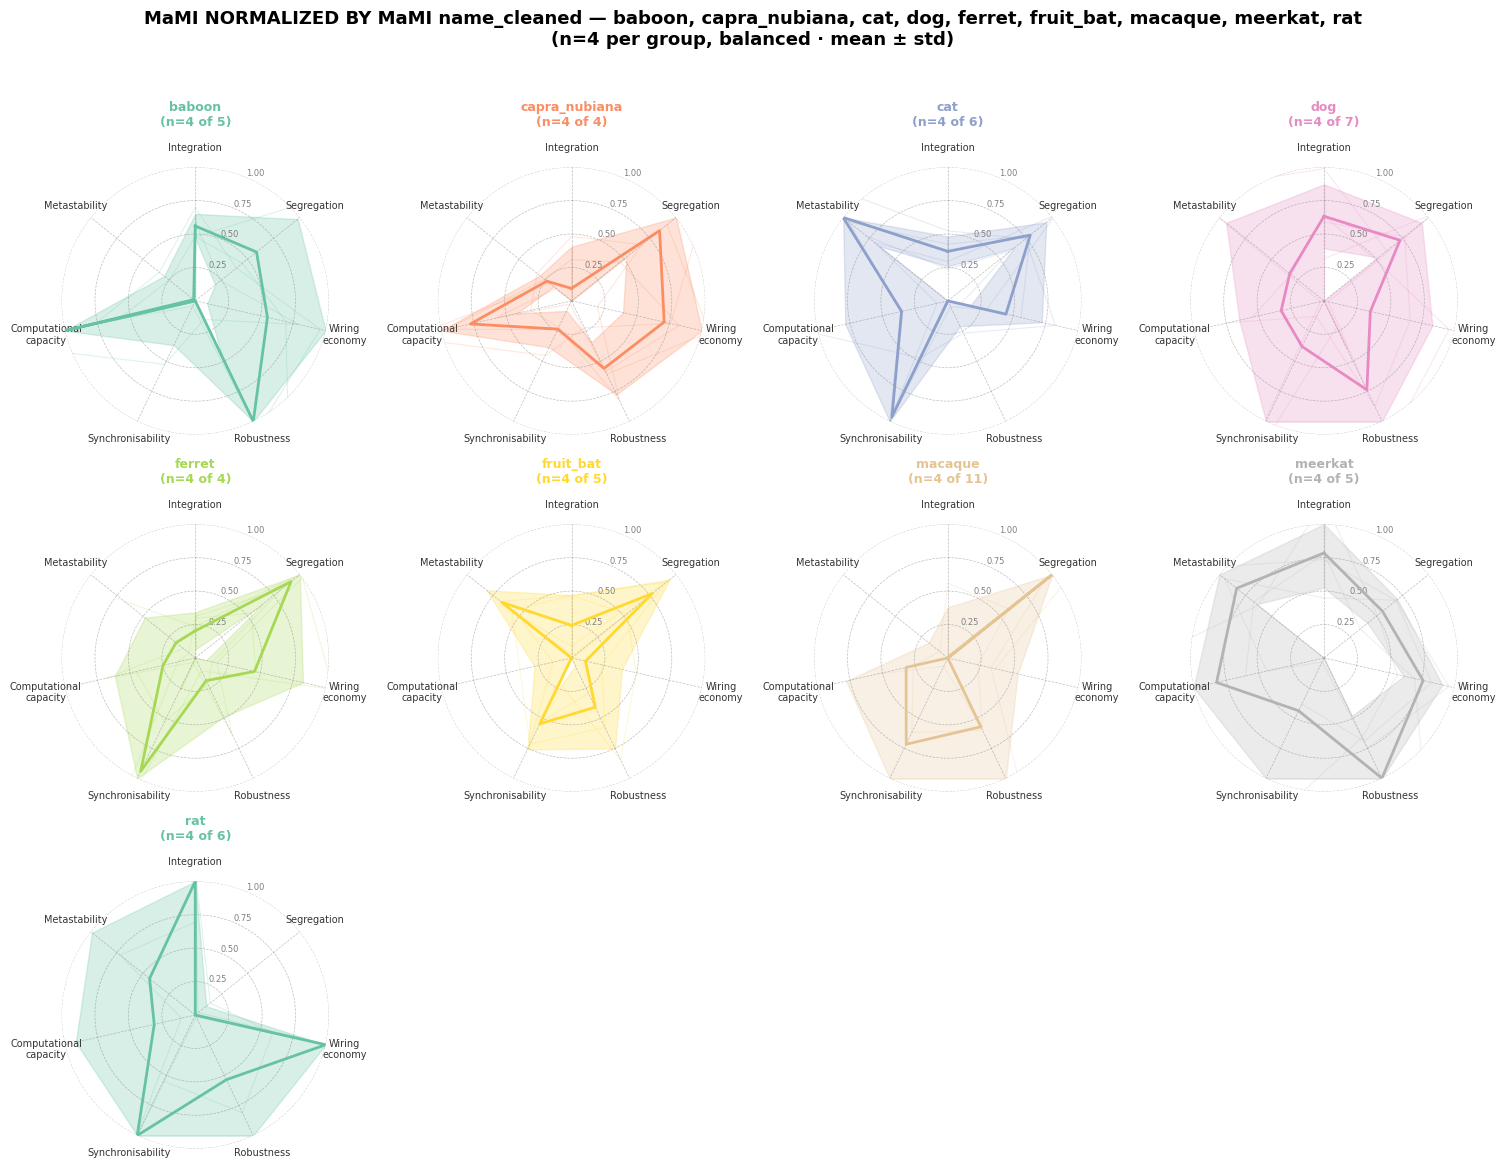

Saved → spider_mami_name_cleaned.png


In [37]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "name_cleaned"
GROUPS_TO_INCLUDE = name_counts.keys()[:9] # [
                #     'Primates',
                #     'Rodentia',
                #     # 'Hyracoidea',
                #     'Carnivora',
                #     # 'Perissodactyla',
                #     # 'Chiroptera',
                #     'Cetartiodactyla',
                #     # 'Eulipotyphla',
                #     # 'Scandentia',
                #     # 'Xenarthra',
                #     # 'Lagomorpha',
                #     # 'Marsupialia'
                # ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

# g_range = COL_RANGE
def normalise_mami(series):
    return (series - g_min) / g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise_mami(mean_raw).values
    # std_n  = (std_raw / COL_RANGE).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]
    ax = axes_flat[idx]
    
    # ── Individual animal contours (low alpha) ────────────────────────────
    group_df = sampled[sampled[what_to_look_at] == group][SELECTED_COLS]
    n_cols   = len(SELECTED_COLS)
    angles   = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
    angles  += angles[:1]  # close the polygon

    for _, row in group_df.iterrows():
        ind_n  = normalise_mami(row).values.tolist()
        ind_n += ind_n[:1]  # close the polygon
        ax.plot(angles, ind_n, color=color, alpha=0.2, # 12, 
                linewidth=0.8)
        # ax.fill(angles, ind_n, color=color, alpha=0.03)
        

    make_spider(
        ax     = ax,
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI NORMALIZED BY MaMI {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")